In [1]:
import wandb

api = wandb.Api(
    api_key="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"
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={"display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_01_04_2026_14"}},
    order="-created_at",
    per_page=10
)


In [ ]:
import pandas as pd

rows = []
for run in runs:
    rows.append({
        "run_id": run.id,
        "name": run.name,
        "state": run.state,
        **dict(run.config),
        **dict(run.summary),
    })

df = pd.DataFrame(rows)

df[['train_dataset', 'eval_dataset', 'shot']] = df.name.str.extract(r"trained_on_(..)_eval_on_(..)_(..?)_shot_01_04_2026_14")
df['shot'] = df['shot'].astype(int)

In [58]:
# plot the matrix

pdf = df[[
"train_dataset",
"eval_dataset",
"shot",
"start_test_acc",
"start_test_acc_std",
"test_accuracy",
"test_f1",
"test_roc_auc",]].dropna()

import seaborn as sns
import matplotlib.pyplot as plt
# pivot_table = df.pivot(index='train_dataset', columns='eval_dataset', values='eval_acc')
pdf.to_clipboard()

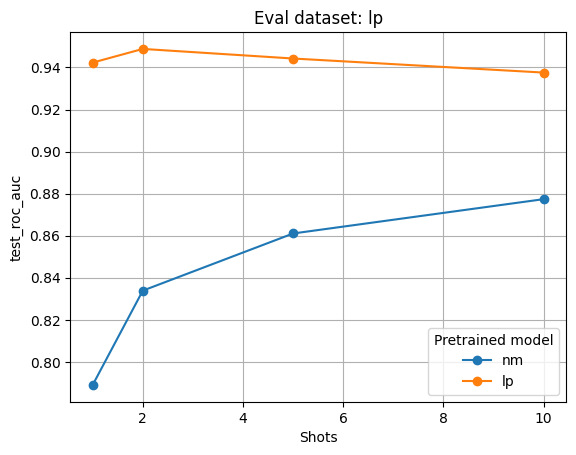

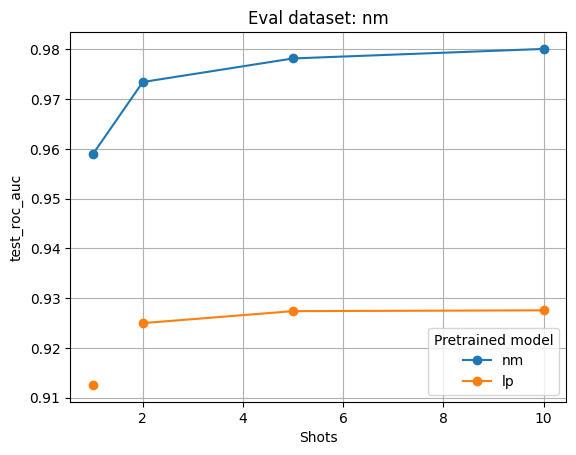

In [63]:
metric = "test_roc_auc"  # change if needed

for eval_ds in df["eval_dataset"].unique():
    plt.figure()
    
    subset = df[df["eval_dataset"] == eval_ds]
    
    for train_ds in subset["train_dataset"].unique():
        sub = subset[subset["train_dataset"] == train_ds].sort_values("shot")
        
        plt.plot(sub["shot"], sub[metric], marker='o', label=train_ds)
    
    plt.title(f"Eval dataset: {eval_ds}")
    plt.xlabel("Shots")
    plt.ylabel(metric)
    plt.legend(title="Pretrained model")
    plt.grid(True)
    
    plt.show()

## PL

In [5]:
# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={"display_name": {"$regex": "trained_on_pl_eval_on_pl_..?_shot_07_04_2026"}},
    order="-created_at",
    per_page=10
)

In [ ]:
import pandas as pd

rows = []
for run in runs:
    rows.append({
        "run_id": run.id,
        "name": run.name,
        "state": run.state,
        **dict(run.config),
        **dict(run.summary),
    })

df = pd.DataFrame(rows)

df[['train_dataset', 'eval_dataset', 'shot']] = df.name.str.extract(r"trained_on_(..)_eval_on_(..)_(..?)_shot")
df['shot'] = df['shot'].astype(int)

In [20]:
df.columns

Index(['run_id', 'name', 'state', 'params', 'trainer_fs', '_runtime', '_step',
       '_timestamp', '_wandb', 'num_params', 'start_test_acc',
       'start_test_acc_std', 'test_accuracy', 'test_class0_acc',
       'test_class1_acc', 'test_f1', 'test_fn', 'test_fp',
       'test_gt_class1_rate', 'test_mean_confidence', 'test_mean_logit_margin',
       'test_mean_p_class1', 'test_mean_p_class1_gt0',
       'test_mean_p_class1_gt1', 'test_mean_true_margin',
       'test_pred_class1_rate', 'test_roc_auc', 'test_tn', 'test_tp',
       'wandb_url', 'train_dataset', 'eval_dataset', 'shot'],
      dtype='str')

<Axes: xlabel='shot'>

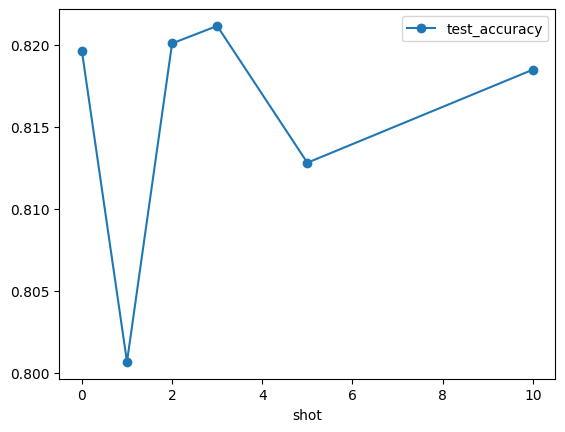

In [21]:
df.plot(x='shot', y='test_accuracy', kind='line', marker='o')